In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier

ModuleNotFoundError: No module named 'lightgbm'

In [2]:
df = pd.read_csv("adult.csv", delimiter=',')

In [3]:
data_cleaned = df.replace('?', np.nan)
data_cleaned['income'] = data_cleaned['income'].apply(lambda x: 1 if x == '>50K' else 0)
data_dropped = data_cleaned.dropna()

In [4]:
data_cleaned = data_dropped.drop(columns=['educational-num'])

In [5]:
for col in data_cleaned.select_dtypes(include=np.number).columns:
    df_encoded = pd.get_dummies(data_cleaned, drop_first=True)

In [6]:
correlation_matrix = df_encoded.corr()
correlation_with_target = correlation_matrix['income'].sort_values(ascending=False)
print(correlation_with_target)

selected_features = correlation_with_target[correlation_with_target.abs() > 0.2].index.tolist()
selected_features.remove('income')  
print("Вибрані ознаки для моделі:", selected_features)

income                               1.000000
marital-status_Married-civ-spouse    0.446192
age                                  0.237040
hours-per-week                       0.227199
capital-gain                         0.221034
                                       ...   
relationship_Unmarried              -0.147262
occupation_Other-service            -0.165428
relationship_Not-in-family          -0.195561
relationship_Own-child              -0.222635
marital-status_Never-married        -0.319536
Name: income, Length: 96, dtype: float64
Вибрані ознаки для моделі: ['marital-status_Married-civ-spouse', 'age', 'hours-per-week', 'capital-gain', 'gender_Male', 'occupation_Exec-managerial', 'relationship_Own-child', 'marital-status_Never-married']


In [9]:
X_1 = df_encoded[['marital-status_Married-civ-spouse', 'age', 'hours-per-week', 'capital-gain', 'gender_Male', 'occupation_Exec-managerial', 'relationship_Own-child', 'marital-status_Never-married']]
y_1 = df_encoded['income']

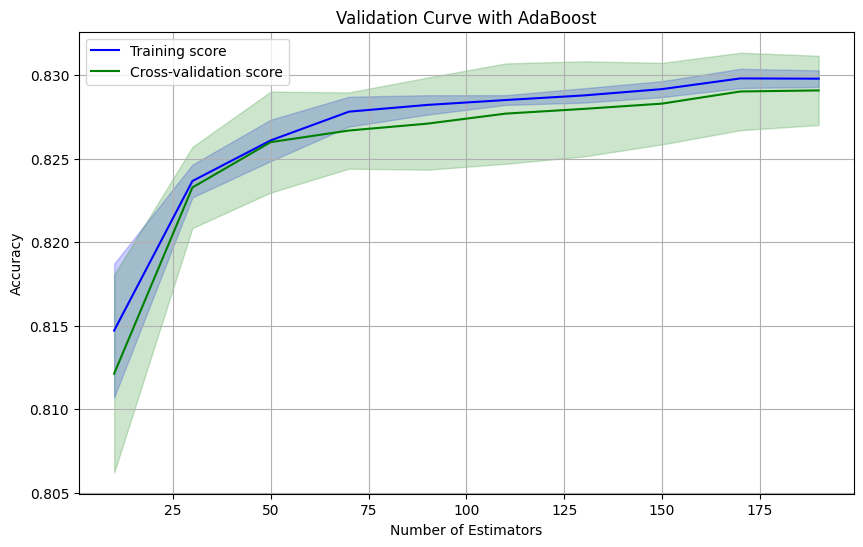

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_1, y_1, test_size=0.3, random_state=42, stratify=y_1)

# AdaBoost
base_model = DecisionTreeClassifier(max_depth=1, random_state=42)
ada_model = AdaBoostClassifier(estimator=base_model, random_state=42)

param_range = np.arange(10, 210, 20)
train_scores, test_scores = validation_curve(
    ada_model, X_train, y_train,
    param_name="n_estimators", param_range=param_range,
    scoring="accuracy", cv=5
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, label="Training score", color="blue")
plt.plot(param_range, test_mean, label="Cross-validation score", color="green")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="green")
plt.title("Validation Curve with AdaBoost")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()

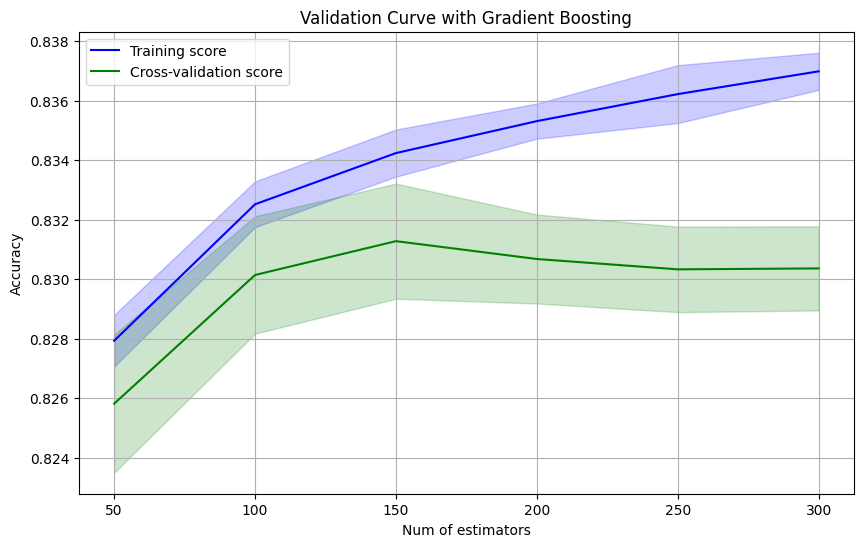

In [13]:
gb_model = GradientBoostingClassifier(random_state=42, max_depth=3)

param_range = np.arange(50, 310, 50)
train_scores, test_scores = validation_curve(
    gb_model, X_train, y_train,
    param_name="n_estimators", param_range=param_range,
    scoring="accuracy", cv=5
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, label="Training score", color="blue")
plt.plot(param_range, test_mean, label="Cross-validation score", color="green")
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="green")
plt.title("Validation Curve with Gradient Boosting")
plt.xlabel("Num of estimators")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()